# COMP262 - Group 5
# Phase 2: Machine Learning Sentiment Analysis

**Dataset:** Amazon Gift Cards Reviews (Gift_Cards_5.json)

**Phase 1 Summary:** Lexicon-based sentiment analysis was carried out using VADER and TextBlob on a sample of 1,000 reviews from the Gift Cards dataset. Both models classified reviews as Positive, Neutral, or Negative based on the cleaned review text. VADER and TextBlob results were evaluated using accuracy, precision, recall, F1, and confusion matrices.

**Phase 2 Objective:** Build two supervised machine learning models for sentiment analysis, fine-tune them, evaluate them against the Phase 1 lexicon baselines on the same data, enhance rating values using review text, and apply local LLM models for summarisation and automated response generation.


---
## Import Libraries

All required libraries are imported here. This includes libraries for data handling, visualisation, text preprocessing, machine learning, evaluation, and Hugging Face model inference.



In [71]:
# !pip install vaderSentiment textblob scikit-learn transformers torch pandas numpy matplotlib seaborn nltk

import warnings
warnings.filterwarnings('ignore')

import sys
print(sys.version)

# Data manipulation
import pandas as pd
import numpy as np
import os
import re

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Text representation
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine learning models
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder

# Model selection and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Lexicon models from Phase 1
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

# Hugging Face
from transformers import pipeline as hf_pipeline

print("All libraries imported successfully.")


3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]
All libraries imported successfully.
All libraries imported successfully.


---
## Section 1 - Load Dataset

We load the same Gift_Cards_5.json dataset used in Phase 1. Each row is one Amazon product review. The key fields used in this phase are:

- reviewText: the raw written review
- overall: the numeric star rating (1 to 5)
- reviewerID: unique user identifier
- asin: unique product identifier


In [10]:
# Update this path to match your local environment
file_path = r"C:\Centennial\WinterSemester2026\NaturalLanguageAndRecommendationSystem\GroupProjectFiles\Phase1\Gift_Cards_5.json\Gift_Cards_5.json"

df = pd.read_json(file_path, lines=True)

print("Total Reviews:", len(df))
print("Average Rating:", round(df['overall'].mean(), 4))
print("Columns:", list(df.columns))
df.info()


Total Reviews: 2972
Average Rating: 4.8853
Columns: ['overall', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'vote', 'image']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2972 entries, 0 to 2971
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   overall         2972 non-null   int64  
 1   verified        2972 non-null   bool   
 2   reviewTime      2972 non-null   object 
 3   reviewerID      2972 non-null   object 
 4   asin            2972 non-null   object 
 5   style           864 non-null    object 
 6   reviewerName    2972 non-null   object 
 7   reviewText      2966 non-null   object 
 8   summary         2972 non-null   object 
 9   unixReviewTime  2972 non-null   int64  
 10  vote            208 non-null    float64
 11  image           12 non-null     object 
dtypes: bool(1), float64(1), int64(2), object(8)
memory usage: 258

---
## Section 2 - Basic Information and Exploration (Full Dataset)

Before selecting our subset we take a quick look at the full dataset to understand the overall distribution of ratings, reviews per product, and reviews per user.


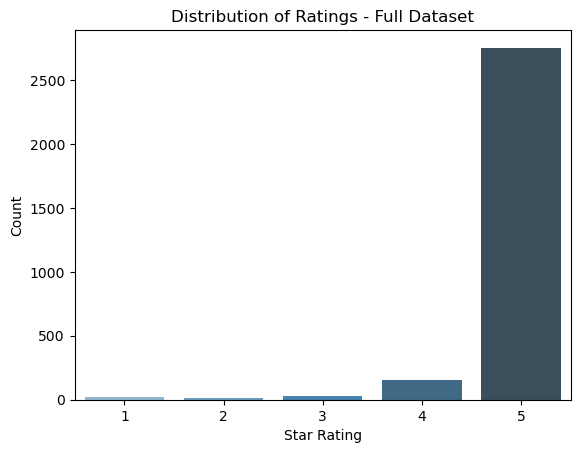

In [11]:
# Rating distribution across the full dataset
sns.countplot(x='overall', data=df, palette='Blues_d')
plt.title("Distribution of Ratings - Full Dataset")
plt.xlabel("Star Rating")
plt.ylabel("Count")
plt.show()


Reviews per product:
count    148.000000
mean      20.081081
std       19.359300
min        4.000000
25%        8.000000
50%       12.000000
75%       26.250000
max       94.000000
dtype: float64


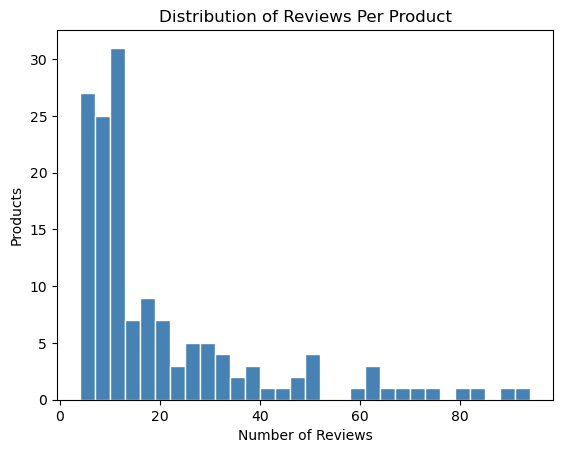

In [12]:
# Reviews per product
reviews_per_product = df.groupby('asin').size()
print("Reviews per product:")
print(reviews_per_product.describe())

plt.hist(reviews_per_product, bins=30, color='steelblue', edgecolor='white')
plt.title("Distribution of Reviews Per Product")
plt.xlabel("Number of Reviews")
plt.ylabel("Products")
plt.show()


Reviews per user:
count    458.000000
mean       6.489083
std        2.710885
min        5.000000
25%        5.000000
50%        6.000000
75%        7.000000
max       32.000000
dtype: float64


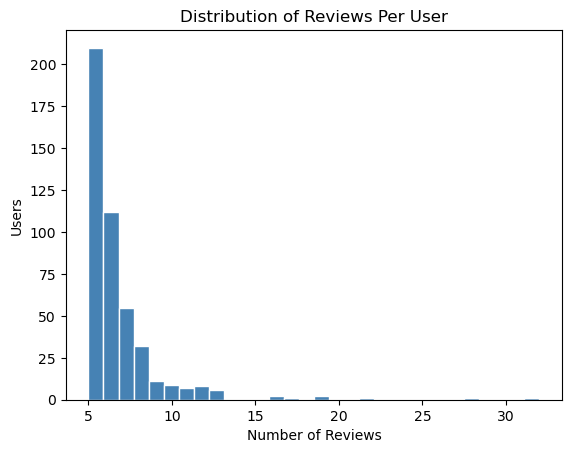

In [13]:
# Reviews per user
reviews_per_user = df.groupby('reviewerID').size()
print("Reviews per user:")
print(reviews_per_user.describe())

plt.hist(reviews_per_user, bins=30, color='steelblue', edgecolor='white')
plt.title("Distribution of Reviews Per User")
plt.xlabel("Number of Reviews")
plt.ylabel("Users")
plt.show()


count    2966.000000
mean       67.467296
std       131.120601
min         2.000000
25%        12.000000
50%        29.000000
75%        72.000000
max      2409.000000
Name: review_length, dtype: float64


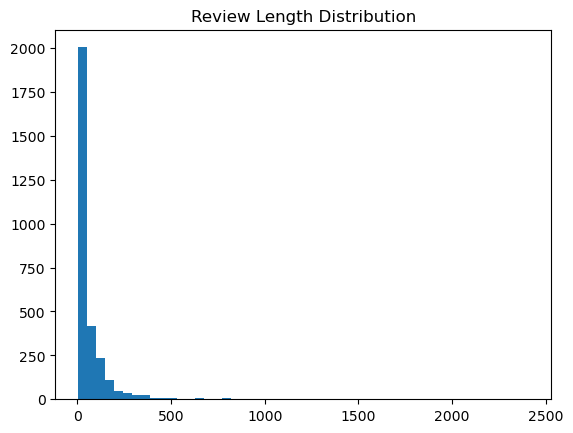

In [14]:
# Look at review length distribution
df['review_length'] = df['reviewText'].str.len()

print(df['review_length'].describe())

plt.hist(df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.show()



In [15]:
# Check for duplicate rows
print("Duplicate Rows:", df.select_dtypes(exclude=['object']).duplicated().sum())


Duplicate Rows: 830


---
## Section 3 - Sentiment Labelling and Text Cleaning (Full Dataset)

We apply the sentiment label and text cleaning to the full dataset before selecting the subset. This ensures the subset we draw already has all fields populated.

The sentiment label is derived from the star rating:
- Rating 4 or 5 maps to Positive
- Rating 3 maps to Neutral
- Rating 1 or 2 maps to Negative


In [16]:
# Sentiment labelling from star rating
def label_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['overall'].apply(label_sentiment)
print("Sentiment distribution (full dataset):")
print(df['sentiment'].value_counts())


Sentiment distribution (full dataset):
sentiment
Positive    2906
Negative      33
Neutral       33
Name: count, dtype: int64


In [17]:
# Text cleaning

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()                           # Step 1: lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)           # Step 2: remove non-alphabetic characters
    words = text.split()                               # Step 3: tokenise
    words = [w for w in words if w not in stop_words] # Step 4: remove stopwords
    words = [lemmatizer.lemmatize(w) for w in words]  # Step 5: lemmatise
    return " ".join(words)

df['cleaned_text'] = df['reviewText'].astype(str).apply(clean_text)

df[['reviewText', 'cleaned_text']].head(3)


,reviewText,cleaned_text
0,Another great gift.,another great gift
1,Gift card for my daughter,gift card daughter
2,Nice present,nice present


---
## Section 4 - Subset Selection

### 11a - Select a minimum of 2,000 reviews

We draw a stratified random sample of 2,000 reviews so that the rating class distribution in the subset reflects the full dataset proportionally.



In [18]:
SAMPLE_SIZE = 2000
RANDOM_STATE = 42

# Stratified sampling to preserve class proportions across star ratings
df_sample, _ = train_test_split(
    df,
    train_size=SAMPLE_SIZE,
    stratify=df['overall'],
    random_state=RANDOM_STATE
)
df_sample = df_sample.reset_index(drop=True)

print("Subset size:", len(df_sample))
print("Rating distribution in subset:")
print(df_sample['overall'].value_counts().sort_index())
print()
print("Sentiment distribution in subset:")
print(df_sample['sentiment'].value_counts())


Subset size: 2000
Rating distribution in subset:
overall
1      15
2       7
3      22
4     104
5    1852
Name: count, dtype: int64

Sentiment distribution in subset:
sentiment
Positive    1956
Negative      22
Neutral       22
Name: count, dtype: int64


---
## Section 5 - Data Exploration on the Subset

### 11b - Carry out data exploration on the subset


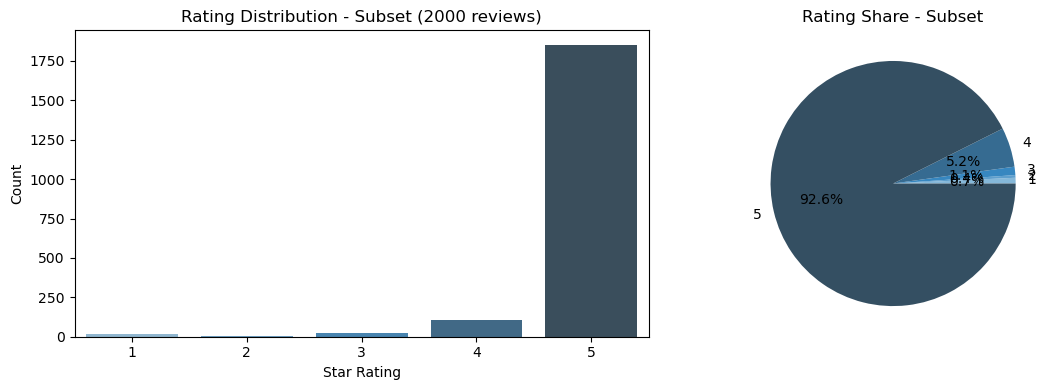

In [19]:
# Rating distribution in the subset
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='overall', data=df_sample, palette='Blues_d', ax=axes[0])
axes[0].set_title("Rating Distribution - Subset (2000 reviews)")
axes[0].set_xlabel("Star Rating")
axes[0].set_ylabel("Count")

df_sample['overall'].value_counts().sort_index().plot.pie(
    autopct='%1.1f%%', ax=axes[1],
    colors=sns.color_palette('Blues_d', 5)
)
axes[1].set_title("Rating Share - Subset")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


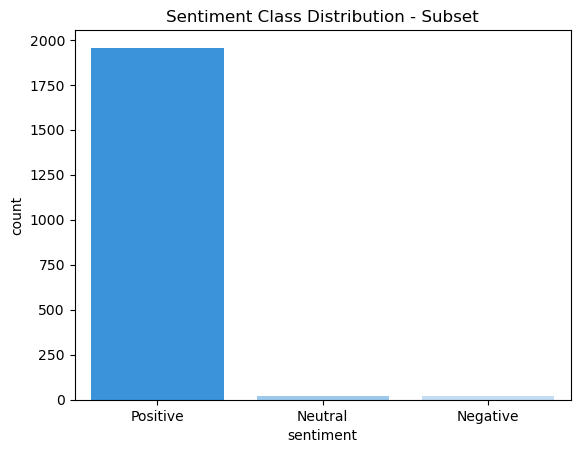

In [20]:
# Sentiment class distribution in the subset
sns.countplot(
    x='sentiment', data=df_sample,
    order=['Positive', 'Neutral', 'Negative'],
    palette=['#2196F3', '#90CAF9', '#BBDEFB']
)
plt.title("Sentiment Class Distribution - Subset")
plt.show()


In [21]:
# Missing values in the subset
print("Missing values per column in subset:")
print(df_sample.isnull().sum())


Missing values per column in subset:
overall              0
verified             0
reviewTime           0
reviewerID           0
asin                 0
style             1427
reviewerName         0
reviewText           5
summary              0
unixReviewTime       0
vote              1867
image             1992
review_length        5
sentiment            0
cleaned_text         0
dtype: int64


In [22]:
# Duplicate check in the subset
dups = df_sample.duplicated(subset=['reviewText']).sum()
print("Duplicate review texts in subset:", dups)


Duplicate review texts in subset: 638


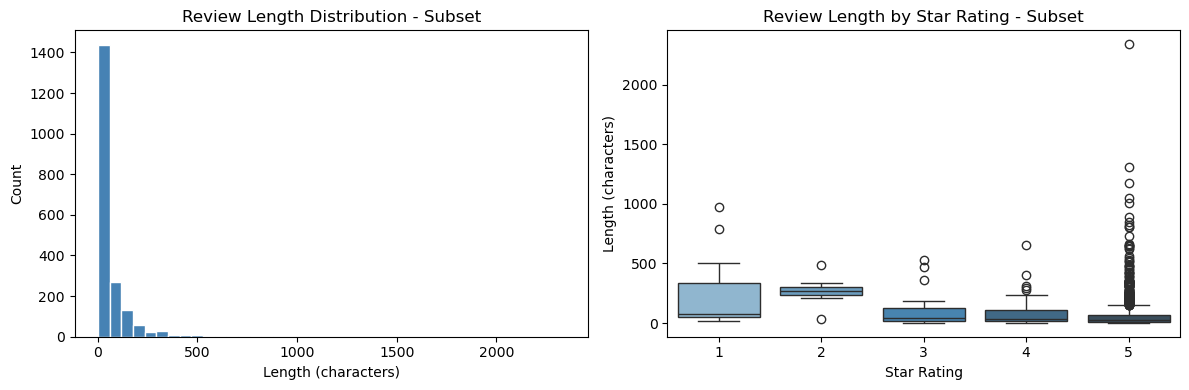

count    1995.000000
mean       65.871679
std       121.397213
min         2.000000
25%        12.000000
50%        29.000000
75%        70.500000
max      2340.000000
Name: review_length, dtype: float64


In [23]:
# Review length distribution in the subset
df_sample['review_length'] = df_sample['reviewText'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_sample['review_length'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title("Review Length Distribution - Subset")
axes[0].set_xlabel("Length (characters)")
axes[0].set_ylabel("Count")

sns.boxplot(x='overall', y='review_length', data=df_sample, palette='Blues_d', ax=axes[1])
axes[1].set_title("Review Length by Star Rating - Subset")
axes[1].set_xlabel("Star Rating")
axes[1].set_ylabel("Length (characters)")

plt.tight_layout()
plt.show()

print(df_sample['review_length'].describe())


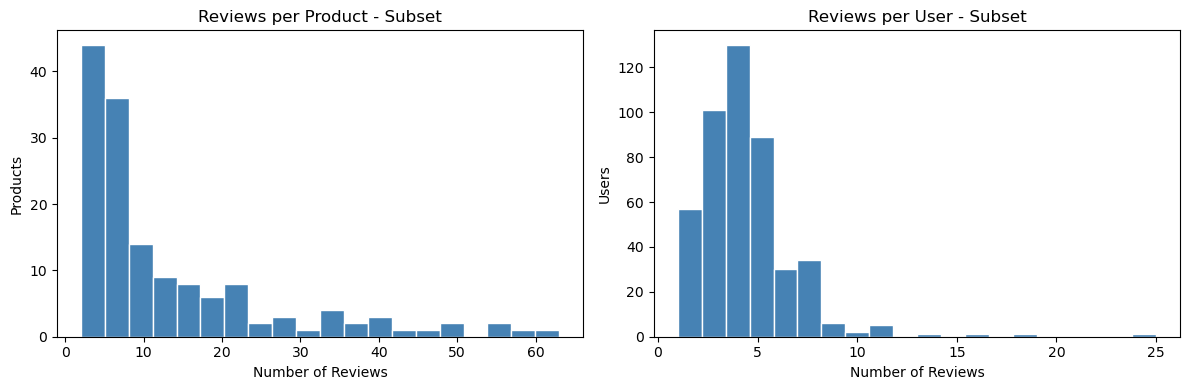

In [24]:
# Reviews per product and per user in the subset
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rpp = df_sample.groupby('asin').size()
axes[0].hist(rpp, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title("Reviews per Product - Subset")
axes[0].set_xlabel("Number of Reviews")
axes[0].set_ylabel("Products")

rpu = df_sample.groupby('reviewerID').size()
axes[1].hist(rpu, bins=20, color='steelblue', edgecolor='white')
axes[1].set_title("Reviews per User - Subset")
axes[1].set_xlabel("Number of Reviews")
axes[1].set_ylabel("Users")

plt.tight_layout()
plt.show()


---
## Section 6 - Text Representation

### 11c - Represent text using one of the course representations

**Chosen Representation: TF-IDF (Term Frequency - Inverse Document Frequency)**

Why TF-IDF was chosen:

First, TF-IDF accounts for word importance across documents. Words that appear in almost every review (such as common adjectives) receive a lower weight, while words that are distinctive to a specific subset of reviews receive a higher weight. This makes the representation more informative for sentiment classification.

Second, TF-IDF is directly compatible with the scikit-learn ML models chosen (Naive Bayes and MLP from sklearn). 

Third, TF-IDF with bigrams captures short phrases such as "not good" or "very happy" which carry stronger sentiment signals than single words alone.

Fourth, TF-IDF was covered as one of the primary text representation methods in the course.

Parameters used:
- max_features=5000: top 5,000 terms by TF-IDF score
- ngram_range=(1,2): unigrams and bigrams
- min_df=2: ignore terms appearing in fewer than 2 documents
- sublinear_tf=True: apply log normalisation to reduce dominance of very frequent terms


In [25]:
# TF-IDF vectorisation
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X = tfidf.fit_transform(df_sample['cleaned_text'])
y = df_sample['sentiment']

print("TF-IDF matrix shape:", X.shape)
print("  That is", X.shape[0], "reviews by", X.shape[1], "features")
print()
print("Class distribution:")
print(y.value_counts())

# Show the top 20 most informative features
feature_names = tfidf.get_feature_names_out()
mean_tfidf = X.mean(axis=0).A1
top_idx = mean_tfidf.argsort()[-20:][::-1]
print()
print("Top 20 features by mean TF-IDF weight:")
print([feature_names[i] for i in top_idx])


TF-IDF matrix shape: (2000, 2226)
  That is 2000 reviews by 2226 features

Class distribution:
sentiment
Positive    1956
Negative      22
Neutral       22
Name: count, dtype: int64

Top 20 features by mean TF-IDF weight:
['gift', 'great', 'card', 'gift card', 'good', 'great gift', 'love', 'nice', 'loved', 'perfect', 'worked', 'christmas', 'amazon', 'work', 'cute', 'always', 'like', 'fast', 'use', 'ok']


---
## Section 7 - Train / Test Split

### 11d - Split 70% training and 30% test with stratified split based on the rating value field

We are using stratify=df_sample['overall'] with a single shared split so both models are trained and tested on identical data, enabling a fair comparison.

We also capture idx_test, the row indices of the test set, so that the Phase 1 lexicon models (VADER and TextBlob) can be run on the exact same rows in Section 9.


In [26]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X,
    y,
    df_sample.index,         # save original row indices for lexicon comparison later
    test_size=0.30,
    stratify=df_sample['overall'],   # stratify on raw star rating as required
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape[0], "samples (", round(X_train.shape[0]/len(df_sample)*100, 1), "%)")
print("Test set    :", X_test.shape[0], "samples (", round(X_test.shape[0]/len(df_sample)*100, 1), "%)")
print()
print("Training class distribution:")
print(y_train.value_counts())
print()
print("Test class distribution:")
print(y_test.value_counts())


Training set: 1400 samples ( 70.0 %)
Test set    : 600 samples ( 30.0 %)

Training class distribution:
sentiment
Positive    1369
Negative      16
Neutral       15
Name: count, dtype: int64

Test class distribution:
sentiment
Positive    587
Neutral       7
Negative      6
Name: count, dtype: int64


---
## Section 8 - Build and Fine-Tune Two ML Models

### 11e, 12, and 13

Two machine learning algorithms are selected from the course list:

1. Naive Bayes (Multinomial NB) - a probabilistic model based on Bayes' theorem. Well suited to TF-IDF sparse matrices. Fast to train and easy to interpret.

2. MLP (Multi-Layer Perceptron) - a feed-forward neural network from scikit-learn. Capable of learning non-linear relationships between features, which may capture more complex sentiment patterns.



### 8.1 - Model 1: Naive Bayes (Multinomial NB)

#### 11e - Build and fine-tune the model


Best Naive Bayes alpha     : 0.1
Best CV F1-weighted score  : 0.9728


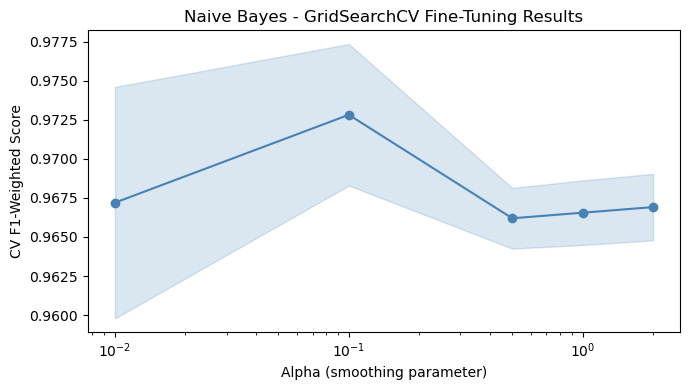

In [27]:
# Fine-tune Naive Bayes using GridSearchCV
nb_param_grid = {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]}

nb_grid = GridSearchCV(
    MultinomialNB(),
    nb_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_weighted',
    n_jobs=-1
)
nb_grid.fit(X_train, y_train)

print("Best Naive Bayes alpha     :", nb_grid.best_params_['alpha'])
print("Best CV F1-weighted score  :", round(nb_grid.best_score_, 4))

nb_best = nb_grid.best_estimator_

# Plot GridSearchCV results
cv_results_nb = pd.DataFrame(nb_grid.cv_results_)
plt.figure(figsize=(7, 4))
plt.plot(nb_param_grid['alpha'], cv_results_nb['mean_test_score'], marker='o', color='steelblue')
plt.fill_between(
    nb_param_grid['alpha'],
    cv_results_nb['mean_test_score'] - cv_results_nb['std_test_score'],
    cv_results_nb['mean_test_score'] + cv_results_nb['std_test_score'],
    alpha=0.2, color='steelblue'
)
plt.xscale('log')
plt.xlabel("Alpha (smoothing parameter)")
plt.ylabel("CV F1-Weighted Score")
plt.title("Naive Bayes - GridSearchCV Fine-Tuning Results")
plt.tight_layout()
plt.show()


#### 12 - Note the results of the training process


In [28]:
# Naive Bayes training results (Requirement 12)
print("=== Naive Bayes - Training Results ===")
nb_train_pred = nb_best.predict(X_train)
print("Training Accuracy:", round(accuracy_score(y_train, nb_train_pred), 4))
print()
print(classification_report(y_train, nb_train_pred, target_names=['Negative', 'Neutral', 'Positive']))


=== Naive Bayes - Training Results ===
Training Accuracy: 0.9893

              precision    recall  f1-score   support

    Negative       0.93      0.81      0.87        16
     Neutral       0.70      0.47      0.56        15
    Positive       0.99      1.00      0.99      1369

    accuracy                           0.99      1400
   macro avg       0.87      0.76      0.81      1400
weighted avg       0.99      0.99      0.99      1400



#### 13 - Test the model and note accuracy, precision, recall, confusion matrix, and F1


=== Naive Bayes - Test Results ===
Accuracy  : 0.975
Precision : 0.9668
Recall    : 0.975
F1-Score  : 0.9709

              precision    recall  f1-score   support

    Negative       0.50      0.50      0.50         6
     Neutral       0.00      0.00      0.00         7
    Positive       0.98      0.99      0.99       587

    accuracy                           0.97       600
   macro avg       0.49      0.50      0.50       600
weighted avg       0.97      0.97      0.97       600



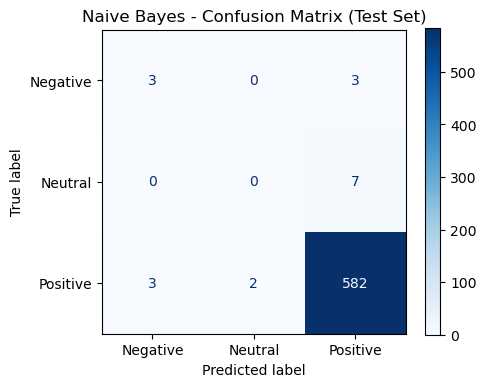

In [29]:
# Naive Bayes test results (Requirement 13)
print("=== Naive Bayes - Test Results ===")
nb_test_pred = nb_best.predict(X_test)

nb_acc = accuracy_score(y_test, nb_test_pred)
nb_pre = precision_score(y_test, nb_test_pred, average='weighted', zero_division=0)
nb_rec = recall_score(y_test, nb_test_pred, average='weighted', zero_division=0)
nb_f1  = f1_score(y_test, nb_test_pred, average='weighted', zero_division=0)

print("Accuracy  :", round(nb_acc, 4))
print("Precision :", round(nb_pre, 4))
print("Recall    :", round(nb_rec, 4))
print("F1-Score  :", round(nb_f1, 4))
print()
print(classification_report(y_test, nb_test_pred, target_names=['Negative', 'Neutral', 'Positive']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, nb_test_pred,
    display_labels=['Negative', 'Neutral', 'Positive'],
    cmap='Blues', ax=ax
)
ax.set_title("Naive Bayes - Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()


### 8.2 - Model 2: MLP (Multi-Layer Perceptron)

#### 11e - Build and fine-tune the model

The sklearn MLPClassifier used here handles multi-class by default.

GridSearchCV is used to find the best hidden layer sizes, regularisation strength (alpha), and learning rate.


In [30]:

# --- 11e: Build and fine-tune the MLP model ---

# 1. Encode labels (CRITICAL: Fixes the 'isnan' TypeError by converting strings to numbers)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# 2. Setup Parameter Grid
mlp_param_grid = {
    'hidden_layer_sizes': [(128, 64), (256, 128)],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.0005]
}

# 3. Initialize GridSearchCV
mlp_grid = GridSearchCV(
    MLPClassifier(
        max_iter=300,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10
    ),
    mlp_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_weighted',
    n_jobs=-1
)

# 4. Fit the model using the numeric labels
print("Training MLP Model with GridSearchCV...")
mlp_grid.fit(X_train, y_train_encoded)

print("Best MLP parameters       :", mlp_grid.best_params_)
print("Best CV F1-weighted score  :", round(mlp_grid.best_score_, 4))

mlp_best = mlp_grid.best_estimator_

Training MLP Model with GridSearchCV...
Best MLP parameters       : {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.0005}
Best CV F1-weighted score  : 0.9673


#### 12 - Note the results of the training process



=== MLP - Training Results ===
Training Accuracy: 0.9779
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        16
     Neutral       0.00      0.00      0.00        15
    Positive       0.98      1.00      0.99      1369

    accuracy                           0.98      1400
   macro avg       0.33      0.33      0.33      1400
weighted avg       0.96      0.98      0.97      1400



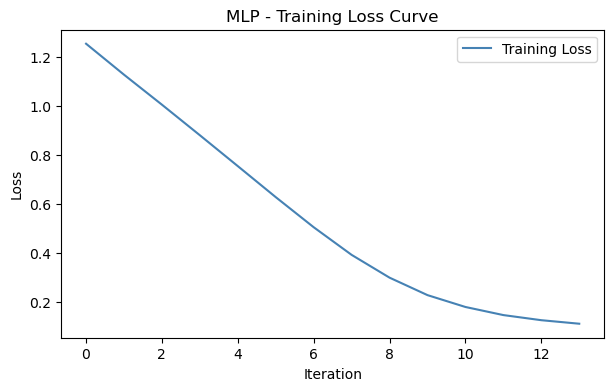

In [31]:
# ---12: Note the results of the training process ---
print("\n=== MLP - Training Results ===")
# Predict numbers, then transform back to strings for the report
mlp_train_pred_num = mlp_best.predict(X_train)
mlp_train_pred = le.inverse_transform(mlp_train_pred_num)

print("Training Accuracy:", round(accuracy_score(y_train, mlp_train_pred), 4))
print(classification_report(y_train, mlp_train_pred))

# Plot training loss
plt.figure(figsize=(7, 4))
plt.plot(mlp_best.loss_curve_, color='steelblue', label='Training Loss')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("MLP - Training Loss Curve")
plt.legend()
plt.show()

#### 13 - Test the model and note accuracy, precision, recall, confusion matrix, and F1



=== MLP - Test Results ===
Accuracy  : 0.9783
Precision : 0.9571
Recall    : 0.9783
F1-Score  : 0.9676

Classification Report (Test Set):
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         6
     Neutral       0.00      0.00      0.00         7
    Positive       0.98      1.00      0.99       587

    accuracy                           0.98       600
   macro avg       0.33      0.33      0.33       600
weighted avg       0.96      0.98      0.97       600



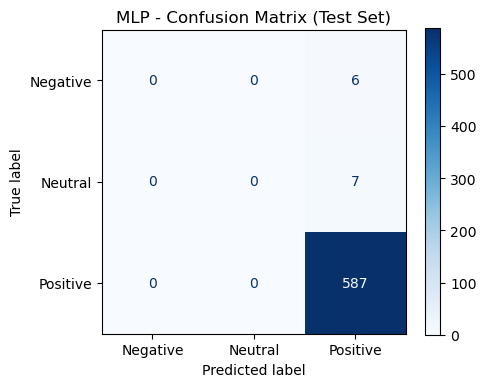

In [32]:
# --- 13: Test the model ---
print("\n=== MLP - Test Results ===")
# Predict numbers, then transform back to strings
mlp_test_pred_num = mlp_best.predict(X_test)
mlp_test_pred = le.inverse_transform(mlp_test_pred_num)

mlp_acc = accuracy_score(y_test, mlp_test_pred)
mlp_pre = precision_score(y_test, mlp_test_pred, average='weighted', zero_division=0)
mlp_rec = recall_score(y_test, mlp_test_pred, average='weighted', zero_division=0)
mlp_f1  = f1_score(y_test, mlp_test_pred, average='weighted', zero_division=0)

print("Accuracy  :", round(mlp_acc, 4))
print("Precision :", round(mlp_pre, 4))
print("Recall    :", round(mlp_rec, 4))
print("F1-Score  :", round(mlp_f1, 4))

print("\nClassification Report (Test Set):")
print(classification_report(y_test, mlp_test_pred))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, mlp_test_pred,
    display_labels=le.classes_,
    cmap='Blues', ax=ax
)
ax.set_title("MLP - Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

---
## Section 9 - Lexicon vs ML Models: Apples-to-Apples Comparison

### 14 - Design an experiment to compare lexicon and ML models on the same data

#### 14a - Prepare the data so both model types run on the same reviews


Step 1: Use the test-set indices saved during the 70/30 split (idx_test) to extract exactly the same 600 rows that the ML models were tested on.

Step 2: Run VADER and TextBlob on the cleaned_text of those same 600 rows.

Step 3: Compare all four models using the same ground truth labels.

This ensures we are comparing apples to apples.


In [33]:
# Step 1: Extract the test rows using the saved indices from Section 7
df_test_rows = df_sample.loc[idx_test].copy()
y_true_comparison = df_test_rows['sentiment'].values

print("Test rows for comparison:", len(df_test_rows))
print("Class distribution:")
print(pd.Series(y_true_comparison).value_counts())


Test rows for comparison: 600
Class distribution:
Positive    587
Neutral       7
Negative      6
Name: count, dtype: int64


In [34]:
# Step 2: Run VADER and TextBlob on the same test rows

analyzer = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

def textblob_sentiment(text):
    score = TextBlob(str(text)).sentiment.polarity
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df_test_rows['vader_pred'] = df_test_rows['cleaned_text'].apply(vader_sentiment)
df_test_rows['textblob_pred'] = df_test_rows['cleaned_text'].apply(textblob_sentiment)

print("Sample of predictions on shared test rows:")
print(df_test_rows[['sentiment', 'vader_pred', 'textblob_pred']].head(5))


Sample of predictions on shared test rows:
     sentiment vader_pred textblob_pred
1186  Negative   Positive      Positive
1033  Positive   Positive      Positive
1567  Positive   Positive       Neutral
1007  Positive   Positive      Positive
1910  Positive   Positive      Negative


In [35]:
# Step 3: Gather all four model predictions on the same rows
vader_preds    = df_test_rows['vader_pred'].values
textblob_preds = df_test_rows['textblob_pred'].values
nb_preds       = nb_test_pred     # from Section 8.1, same test split
mlp_preds      = mlp_test_pred    # from Section 8.2, same test split

def eval_metrics(y_true, y_pred, name):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'F1'       : round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4)
    }

comparison_df = pd.DataFrame([
    eval_metrics(y_true_comparison, vader_preds,    'VADER (Lexicon)'),
    eval_metrics(y_true_comparison, textblob_preds, 'TextBlob (Lexicon)'),
    eval_metrics(y_true_comparison, nb_preds,       'Naive Bayes (ML)'),
    eval_metrics(y_true_comparison, mlp_preds,      'MLP (ML)'),
])

print("=== All Models Compared on the Same 30% Test Set ===")
print(comparison_df.to_string(index=False))


=== All Models Compared on the Same 30% Test Set ===
             Model  Accuracy  Precision  Recall     F1
   VADER (Lexicon)    0.8867     0.9677  0.8867 0.9247
TextBlob (Lexicon)    0.7633     0.9662  0.7633 0.8515
  Naive Bayes (ML)    0.9750     0.9668  0.9750 0.9709
          MLP (ML)    0.9783     0.9571  0.9783 0.9676


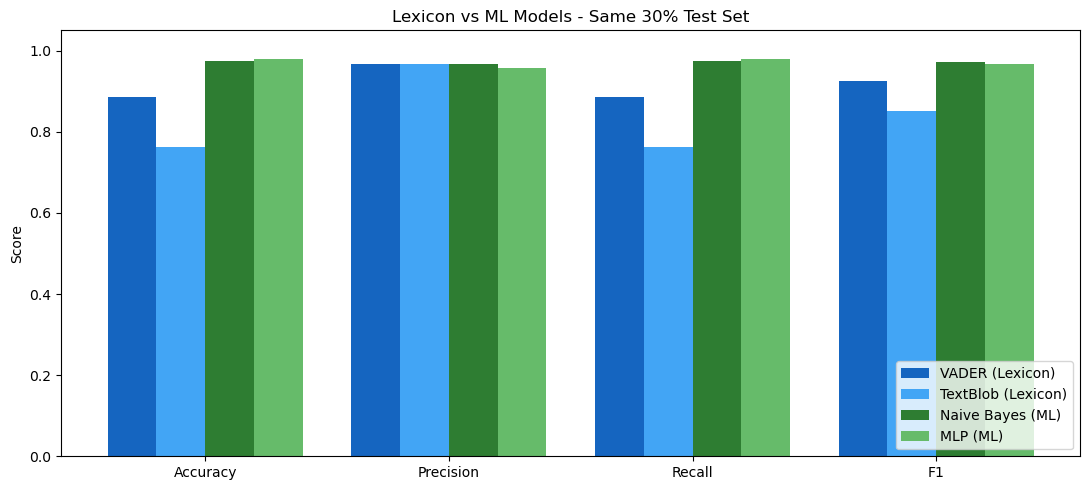

In [36]:
# Grouped bar chart comparing all four models
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
width = 0.2
colors = ['#1565C0', '#42A5F5', '#2E7D32', '#66BB6A']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (_, row) in enumerate(comparison_df.iterrows()):
    ax.bar(x + i * width, [row[m] for m in metrics], width, label=row['Model'], color=colors[i])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Lexicon vs ML Models - Same 30% Test Set")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


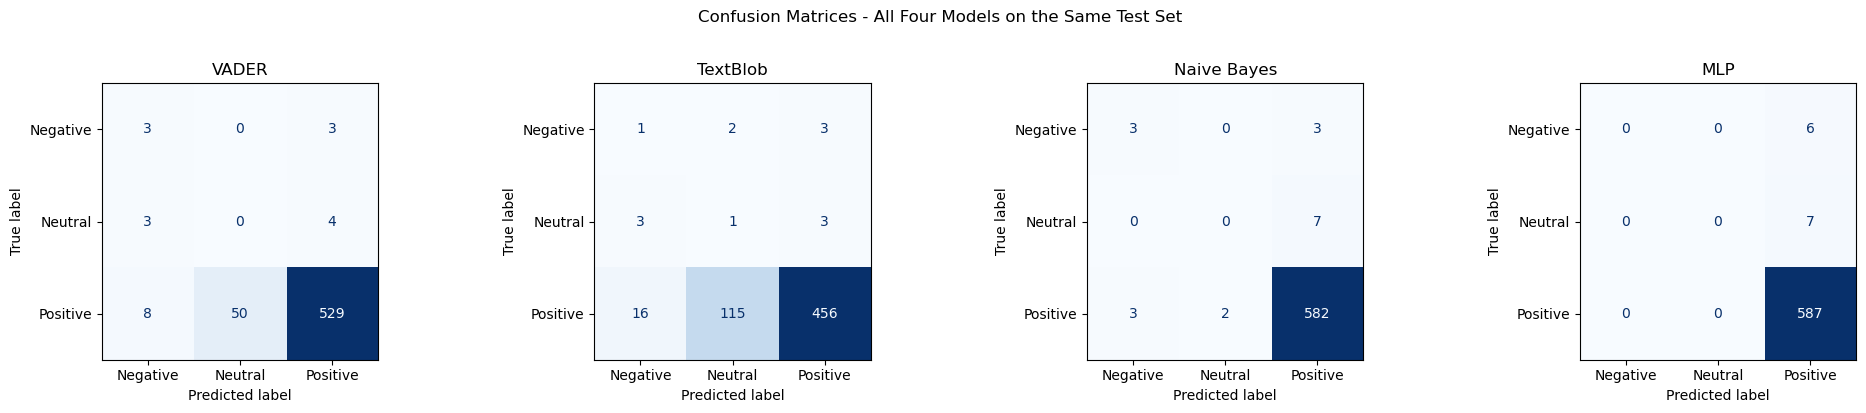

In [37]:
# Confusion matrices for all four models side by side
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
labels = ['Negative', 'Neutral', 'Positive']
model_data = [
    ('VADER',       y_true_comparison, vader_preds),
    ('TextBlob',    y_true_comparison, textblob_preds),
    ('Naive Bayes', y_true_comparison, nb_preds),
    ('MLP',         y_true_comparison, mlp_preds)
]
for ax, (name, yt, yp) in zip(axes, model_data):
    ConfusionMatrixDisplay.from_predictions(
        yt, yp, display_labels=labels,
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(name)

plt.suptitle("Confusion Matrices - All Four Models on the Same Test Set", y=1.02)
plt.tight_layout()
plt.show()


---
## Section 10 - Enhancing Rating Values Using Review Text

### 15 - Based on the recommender systems paper

#### 15a - How review text can enhance rating values


Traditional recommender systems rely on numeric star ratings alone. These ratings suffer from several limitations:

Rating sparsity: most users rate only a small number of items, leaving most user-item pairs unobserved.

Rating inconsistency: different users apply the same numeric scale differently. One user's 3-star may reflect mild satisfaction while another's reflects disappointment.

Information loss: a single integer discards all the nuanced information present in the written review.

The paper "Recommender systems based on user reviews: the state of the art" identifies sentiment-adjusted ratings as one enhancement strategy. By extracting a continuous sentiment signal from the review text and blending it with the original star rating, we can produce an enhanced rating that is more informative and more consistent across users.

#### 15b - Chosen method: Sentiment-Weighted Adjusted Rating

The method works as follows. We compute the VADER compound score from the review text, which is a continuous value between -1 and +1. We normalise both the compound score and the original star rating to the range [0, 1], then blend them using a weighted average controlled by a parameter alpha. The blended value is then rescaled back to the [1, 5] range to match the original rating scale.

Formula:

    vader_normalised  = (compound + 1) / 2         maps [-1, 1] to [0, 1]
    star_normalised   = (overall - 1) / 4           maps [1, 5] to [0, 1]
    blended_norm      = alpha * star_normalised + (1 - alpha) * vader_normalised
    enhanced_rating   = blended_norm * 4 + 1        maps [0, 1] back to [1, 5]

Alpha = 0.6 gives 60% weight to the original star rating and 40% to the text-derived sentiment.

Pseudo-code:

    For each review r in dataset:
        1. compound        = VADER_compound(r.reviewText)
        2. v_norm          = (compound + 1) / 2
        3. s_norm          = (r.overall - 1) / 4
        4. blended         = alpha * s_norm + (1 - alpha) * v_norm
        5. enhanced_rating = blended * 4 + 1
    Return dataset with new column enhanced_rating


#### 15c - Implementation


In [38]:
# Implementation: sentiment-weighted adjusted rating
ALPHA = 0.6

def compute_enhanced_rating(row, alpha=ALPHA):
    compound  = analyzer.polarity_scores(str(row['reviewText']))['compound']
    v_norm    = (compound + 1) / 2          # normalise compound score to [0, 1]
    s_norm    = (row['overall'] - 1) / 4    # normalise star rating to [0, 1]
    blended   = alpha * s_norm + (1 - alpha) * v_norm
    return round(blended * 4 + 1, 4)        # rescale back to [1, 5]

df_sample['enhanced_rating'] = df_sample.apply(compute_enhanced_rating, axis=1)

print("=== Enhanced Rating Results - First 10 Rows ===")
print(df_sample[['reviewText', 'overall', 'enhanced_rating']].head(10).to_string())


=== Enhanced Rating Results - First 10 Rows ===
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          reviewText  overall  enhanced_rating
0                                                                                                                                                                                                                                                                                                                                                                                                                        

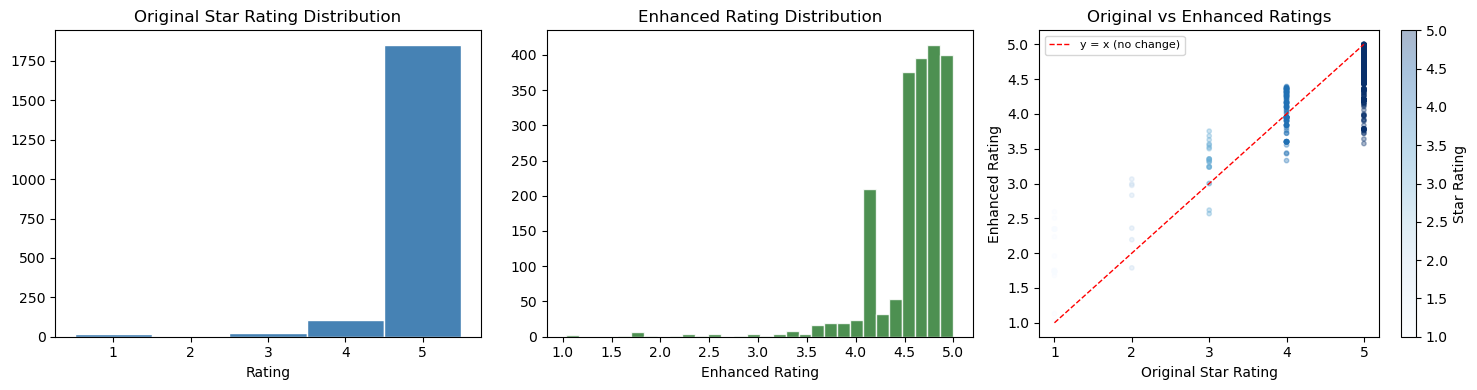

=== Statistical Comparison ===
         overall  enhanced_rating
count  2000.0000        2000.0000
mean      4.8855           4.5922
std       0.4843           0.4092
min       1.0000           1.0375
25%       5.0000           4.5372
50%       5.0000           4.6999
75%       5.0000           4.8325
max       5.0000           4.9988


In [39]:
# Visualise original vs enhanced ratings
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_sample['overall'], bins=5, range=(0.5, 5.5),
             color='steelblue', edgecolor='white')
axes[0].set_title("Original Star Rating Distribution")
axes[0].set_xlabel("Rating")
axes[0].set_xticks([1, 2, 3, 4, 5])

axes[1].hist(df_sample['enhanced_rating'], bins=30,
             color='#2E7D32', edgecolor='white', alpha=0.85)
axes[1].set_title("Enhanced Rating Distribution")
axes[1].set_xlabel("Enhanced Rating")

sc = axes[2].scatter(
    df_sample['overall'],
    df_sample['enhanced_rating'],
    c=df_sample['overall'], cmap='Blues',
    alpha=0.35, s=10
)
axes[2].plot([1, 5], [1, 5], 'r--', linewidth=1, label='y = x (no change)')
axes[2].set_xlabel("Original Star Rating")
axes[2].set_ylabel("Enhanced Rating")
axes[2].set_title("Original vs Enhanced Ratings")
axes[2].legend(fontsize=8)
plt.colorbar(sc, ax=axes[2], label='Star Rating')

plt.tight_layout()
plt.show()

print("=== Statistical Comparison ===")
print(df_sample[['overall', 'enhanced_rating']].describe().round(4))


In [40]:
# Identify cases where text sentiment strongly disagrees with the star rating
df_sample['rating_diff'] = abs(df_sample['enhanced_rating'] - df_sample['overall'])

high_disagreement = df_sample[df_sample['rating_diff'] > 1.5].sort_values(
    'rating_diff', ascending=False
)

print("Reviews where text sentiment strongly disagrees with the star rating:", len(high_disagreement))
print()
print(high_disagreement[['overall', 'enhanced_rating', 'rating_diff', 'reviewText']].head(5).to_string())


Reviews where text sentiment strongly disagrees with the star rating: 2

      overall  enhanced_rating  rating_diff                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

---
## Section 11 - LLM Summarisation Using a Local Hugging Face Model

### 16 - Select 10 reviews with more than 100 words and summarise to 50 words using a local LLM

We use the Qwen/Qwen2.5-0.5B-Instruct model loaded locally via the Hugging Face transformers library. This is a lightweight instruction-tuned model that can run on CPU.




In [41]:
# Select 10 reviews with more than 100 words from the subset
# Using word count on original reviewText (not cleaned_text)
df_sample['word_count'] = df_sample['reviewText'].apply(lambda t: len(str(t).split()))

long_reviews = df_sample[df_sample['word_count'] > 100].sample(
    n=10, random_state=RANDOM_STATE
).reset_index(drop=True)

print("Reviews in subset with more than 100 words:", (df_sample['word_count'] > 100).sum())
print("Selected 10 reviews, word counts:", long_reviews['word_count'].tolist())


Reviews in subset with more than 100 words: 25
Selected 10 reviews, word counts: [162, 223, 252, 191, 122, 120, 123, 120, 121, 180]


In [42]:
# Load the summarisation model locally (runs on CPU by default)
summarizer = hf_pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-0.5B-Instruct",
    device=-1    # use -1 for CPU, change to 0 if a GPU is available
)
print("Summarisation model loaded successfully.")


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Summarisation model loaded successfully.


In [43]:
# Summarise all 10 reviews
summaries = []

for i, row in long_reviews.iterrows():
    messages = [{
        "role": "user",
        "content": (
            # Use triple quotes here to allow the multi-line prompt
            """You are an assistant. Summarise the following customer review 
            in 50 words or fewer. Return only the summary with no extra text.

            Review: """ + row['reviewText']
        )
    }]
    out = summarizer(messages, max_new_tokens=80, do_sample=False)
    
    # Note: Depending on your transformers version, you might need to check the output structure
    summary = out[0]['generated_text'][-1]['content'].strip()
    summaries.append(summary)
    
    print(f"Review {i + 1} ({row['word_count']} words):")
    print("Original:", row['reviewText'][:200], "...")
    print("Summary :", summary)
    print()

long_reviews['summary'] = summaries

Review 1 (162 words):
Original: As you can see, it's very cute. I ordered different gift cards in various dollar amounts, but I kept each gift card style to the amount the same, i.e. the mini-Amazon boxes contained only $50 gift car ...
Summary : The reviewer found the gift card packaging to be cute and appreciated the variety of styles available. However, they were disappointed when they couldn't unwrap all the gift cards due to the lack of dollar amounts on the packaging. Despite this, they enjoyed the unique design and thought it was a fun way to give gifts. The reviewer also mentions that Amazon likely uses math and magic to make gift cards more valuable.

Review 2 (223 words):
Original: It's day 78 on the road since we left. Our full story @ earthen_religion on Instagram & YouTube.
I am not into panhandling or begging since we ( Two Border Collies) set out to move. But when the weath ...
Summary : Summary: Despite initial reluctance due to lack of resources, the reviewer found joy

In [44]:
# Report Record: First two reviews and their summaries
print("=" * 60)
print("REPORT RECORD - FIRST TWO SUMMARISED REVIEWS")
print("=" * 60)

for i in range(2):
    print()
    print("Review", i + 1)
    print("Original Text:")
    print(long_reviews.loc[i, 'reviewText'])
    print()
    print("50-Word Summary:")
    print(long_reviews.loc[i, 'summary'])
    print()


REPORT RECORD - FIRST TWO SUMMARISED REVIEWS

Review 1
Original Text:
As you can see, it's very cute. I ordered different gift cards in various dollar amounts, but I kept each gift card style to the amount the same, i.e. the mini-Amazon boxes contained only $50 gift cards. Thank goodness because each box was shrink-wrapped because there was no indication of the dollar amount on the box itself and I was much too lazy to unwrap them to check them all.

But, if you felt compelled to rip off the shrink-wrap, you can open the box and check because it's not a taped box - it's MAGNETIC!! Yes, the box is held closed by hidden magnetic force, which isn't strong but is strong enough to keep the box closed. Amazing!

I don't know how Amazon makes money off of these clever gift card containers that are shipped, but I'm sure there's some mathematical and habitual wizardry regarding gift cards and spending.

This is a fun way to make gift card giving more fun.

50-Word Summary:
The reviewer found th

---
## Section 12 - LLM Service Representative Response Using a Local Hugging Face Model

### 17 - Select one question-style review and generate an automated service rep response

We use the same locally hosted Qwen/Qwen2.5-0.5B-Instruct model from Section 11.



In [45]:
# Find reviews that contain a question mark and are at least 20 words
question_reviews = df_sample[
    df_sample['reviewText'].str.contains(r'\?', na=False) &
    (df_sample['word_count'] >= 20)
].copy()

print("Reviews with a question and at least 20 words:", len(question_reviews))

# Select the first qualifying review
selected_q = question_reviews.iloc[0]

print()
print("=== Selected Question Review ===")
print("Rating:", selected_q['overall'], "stars")
print("Text  :")
print(selected_q['reviewText'])


Reviews with a question and at least 20 words: 20

=== Selected Question Review ===
Rating: 5 stars
Text  :
Amazon gift card in an adorable cupcake shaped tin- what's not to love? The Amazon card makes a great gift & the bonus tin is "icing on the cake". ;)  The bonus tin is about 4" x 4.5" & one of the cutest ways to give a gift card as a gift. The inside has a removable black lining insert to hold the gift card. The back has a clear window, & says "Amazon gift cards" in very small print.  The tin is reusable & can be used to hold other small items or change. Very nice that Amazon offers this adorable tin with their gift cards.

Amazon gift cards make a great gift because the selection of products offered on this website is Huge!  Unlike giving a gift card to a specific store, restaurant, or for a specific item (i.e. movie tickets, waterparks, etc), an Amazon gift card can be used for whatever the receiver wants. That's a huge perk in gift giving. Other recommendations: Buy it to have

In [46]:
# Generate service representative response
service_prompt = [
    {
        "role": "system",
        "content": (
            "You are a professional and empathetic customer service representative "
            "for an Amazon Gift Cards product. Respond politely, address the "
            "customer's concern directly, and offer helpful next steps."
        )
    },
    {
        "role": "user",
        "content": "Customer review: " + selected_q['reviewText']
    }
]

response_out = summarizer(service_prompt, max_new_tokens=150, do_sample=False)
service_response = response_out[0]['generated_text'][-1]['content'].strip()

print("=== Generated Service Representative Response ===")
print(service_response)


=== Generated Service Representative Response ===
That sounds like a delightful experience! I'm glad you found the Amazon gift card to be both fun and useful. Here are some additional tips to help you use it effectively:

1. **Use It Promptly**: Since Amazon gift cards are typically used within a few days, consider using them before they expire. This way, you won't have to wait until the expiration date to redeem them.

2. **Keep Them Safe**: If you do decide to use the gift card, keep it safe. Most gift cards come with a secure envelope or a sticker that indicates how long to keep them. Make sure to place them in a secure location away from prying eyes.

3. **Track Your Gift Card**: Many gift cards include tracking information. Use


In [47]:
# Report Record
print("=" * 60)
print("REPORT RECORD - SERVICE REPRESENTATIVE RESPONSE")
print("=" * 60)
print()
print("Customer Review:")
print(selected_q['reviewText'])
print()
print("Generated Response:")
print(service_response)


REPORT RECORD - SERVICE REPRESENTATIVE RESPONSE

Customer Review:
Amazon gift card in an adorable cupcake shaped tin- what's not to love? The Amazon card makes a great gift & the bonus tin is "icing on the cake". ;)  The bonus tin is about 4" x 4.5" & one of the cutest ways to give a gift card as a gift. The inside has a removable black lining insert to hold the gift card. The back has a clear window, & says "Amazon gift cards" in very small print.  The tin is reusable & can be used to hold other small items or change. Very nice that Amazon offers this adorable tin with their gift cards.

Amazon gift cards make a great gift because the selection of products offered on this website is Huge!  Unlike giving a gift card to a specific store, restaurant, or for a specific item (i.e. movie tickets, waterparks, etc), an Amazon gift card can be used for whatever the receiver wants. That's a huge perk in gift giving. Other recommendations: Buy it to have on hand as a gift. You never know when yo

---
## Section 13 - Full Results Summary for Report

This section consolidates all evaluation metrics in one place for easy reference when writing the report.


In [48]:
print("=" * 60)
print("PHASE 2 - COMPLETE MODEL EVALUATION SUMMARY")
print("All models evaluated on the same 30% test split")
print("=" * 60)
print()
print(comparison_df.to_string(index=False))

print()
print("=" * 60)
print("RATING ENHANCEMENT SUMMARY")
print("=" * 60)
print(df_sample[['overall', 'enhanced_rating']].describe().round(4))

print()
print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)
best_model = comparison_df.loc[comparison_df['F1'].idxmax(), 'Model']
best_f1    = comparison_df['F1'].max()
print("Best model by weighted F1 :", best_model, "(", best_f1, ")")
for _, row in comparison_df.iterrows():
    print(row['Model'], "Accuracy:", row['Accuracy'], "  F1:", row['F1'])


PHASE 2 - COMPLETE MODEL EVALUATION SUMMARY
All models evaluated on the same 30% test split

             Model  Accuracy  Precision  Recall     F1
   VADER (Lexicon)    0.8867     0.9677  0.8867 0.9247
TextBlob (Lexicon)    0.7633     0.9662  0.7633 0.8515
  Naive Bayes (ML)    0.9750     0.9668  0.9750 0.9709
          MLP (ML)    0.9783     0.9571  0.9783 0.9676

RATING ENHANCEMENT SUMMARY
         overall  enhanced_rating
count  2000.0000        2000.0000
mean      4.8855           4.5922
std       0.4843           0.4092
min       1.0000           1.0375
25%       5.0000           4.5372
50%       5.0000           4.6999
75%       5.0000           4.8325
max       5.0000           4.9988

KEY FINDINGS
Best model by weighted F1 : Naive Bayes (ML) ( 0.9709 )
VADER (Lexicon) Accuracy: 0.8867   F1: 0.9247
TextBlob (Lexicon) Accuracy: 0.7633   F1: 0.8515
Naive Bayes (ML) Accuracy: 0.975   F1: 0.9709
MLP (ML) Accuracy: 0.9783   F1: 0.9676
